In [1]:
!pip install segmentation-models-pytorch torch torchmetrics albumentations

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.3/121.3 kB 8.7 MB/s eta 0:00:00
  Created wheel for efficientnet-pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16424 sha256=3bb9cb51a31a06a2575b7a3e03749c6503c7e4d3ccec98b421212f222815efe7
  Stored in directory: /root/.cache/pip/wheels/03/3f/e9/911b1bc46869644912bda90a56bcf7b960f20b5187feea3baf
  Created wheel for pretrainedmodels: filename=pretrainedmodels-0.7.4-py3-none-any.whl size=60944 sha256=dbcfaed88300de5247085faa42059ceb949245678e52d4a175da5b809f18980a
  Stored in directory: /root/.cache/pip/wheels/35/cb/a5/8f534c60142835bfc889f9a482e4a67e0b817032d9c6883b64
Successfully built efficientnet-pytorch pretrainedmodels


In [2]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
from torchmetrics.classification import BinaryJaccardIndex, BinaryAccuracy
from torchmetrics import Dice
import torchvision.models as models
import torch.nn.functional as F
from torch.nn import init
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from sklearn.model_selection import train_test_split

from albumentations.pytorch import ToTensorV2
import albumentations as A
import segmentation_models_pytorch as smp

/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.5 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [3]:
BASE_DATA_DIR = "/kaggle/input/kvasir-segmentation/Kvasir-SEG"  # Change this to the folder containing "images" and "masks"
IMAGE_DIR = os.path.join(BASE_DATA_DIR, "images")
MASK_DIR  = os.path.join(BASE_DATA_DIR, "masks")

image_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.lower().endswith('.jpg')])
mask_files  = sorted([f for f in os.listdir(MASK_DIR) if f.lower().endswith('.jpg')])

print("Number of images:", len(image_files))
print("Number of masks:", len(mask_files))

Number of images: 1000
Number of masks: 1000


Resolution statistics:
             Width       Height
count  1000.000000  1000.000000
mean    625.292000   545.228000
std     129.621142    90.690798
min     332.000000   352.000000
25%     591.750000   529.000000
50%     621.000000   530.000000
75%     622.000000   531.000000
max    1920.000000  1072.000000


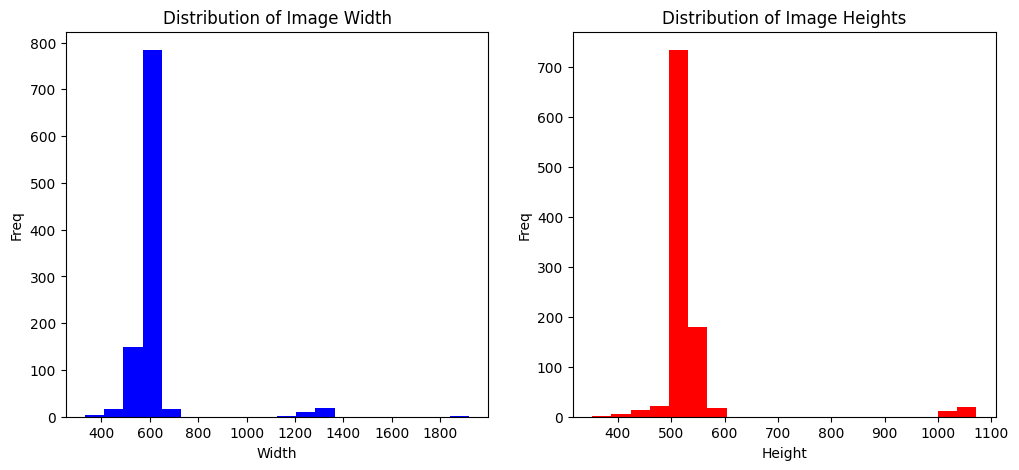

In [4]:
resolutions = []
for f in image_files:
    img_path = os.path.join(IMAGE_DIR, f)
    img = cv2.imread(img_path)
    if img is None:
        continue
    h, w = img.shape[:2]
    resolutions.append((w, h))

res_df = pd.DataFrame(resolutions, columns=['Width', 'Height'])
print("Resolution statistics:")
print(res_df.describe())

# Plot histogram of widths and heights.
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(res_df['Width'], bins=20, color='b')
plt.title('Distribution of Image Width')
plt.xlabel('Width')
plt.ylabel('Freq')

plt.subplot(1, 2, 2)
plt.hist(res_df['Height'], bins=20, color='r')
plt.title('Distribution of Image Heights')
plt.xlabel('Height')
plt.ylabel('Freq')

plt.show()

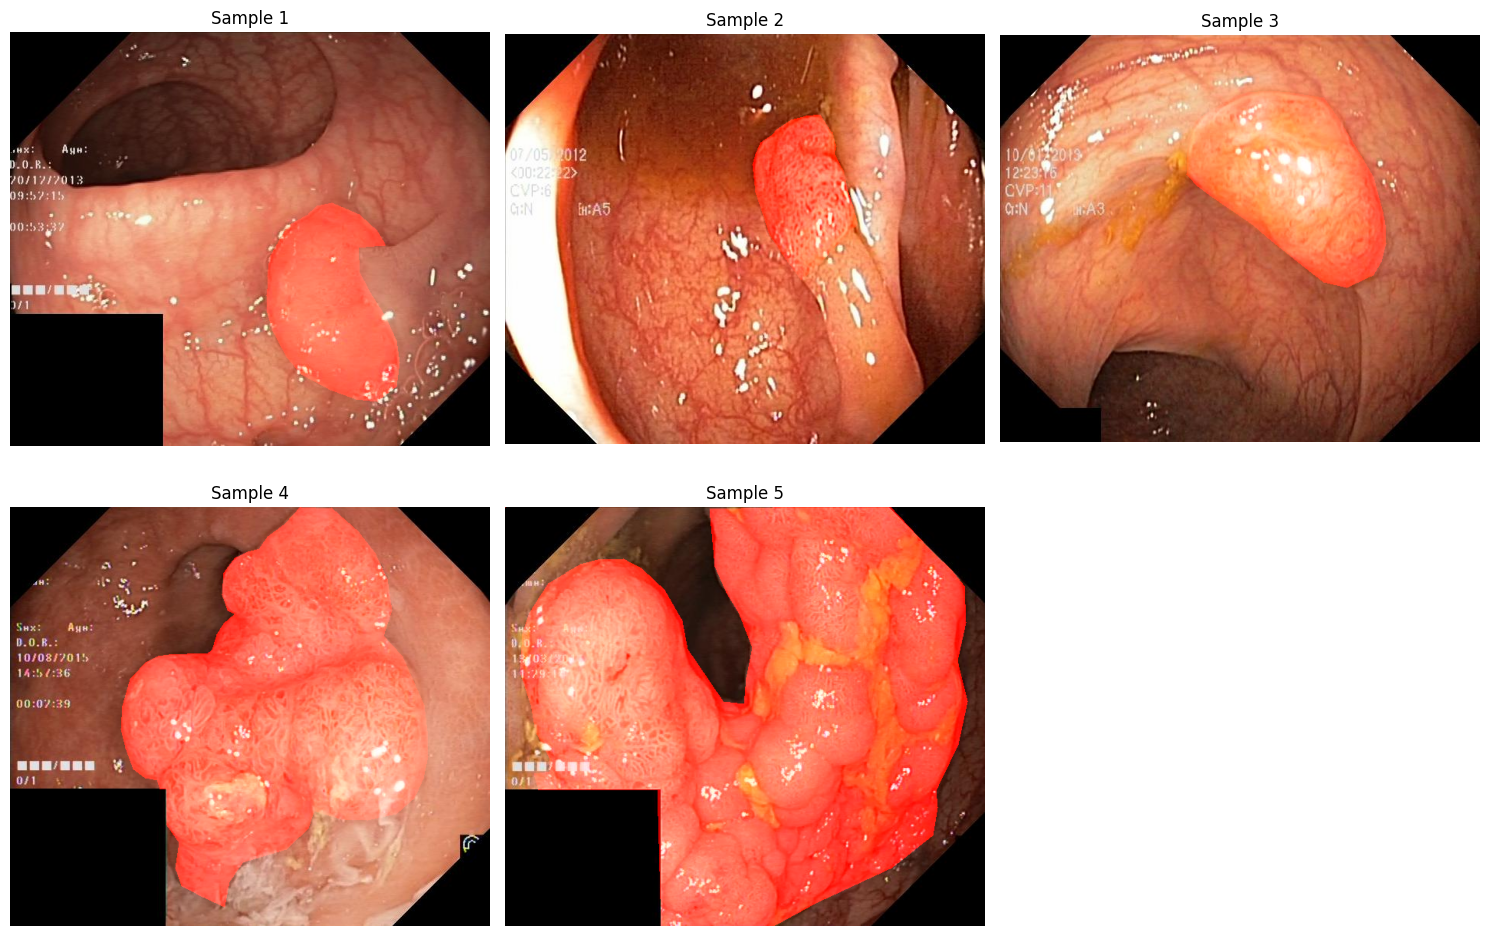

In [5]:
def overlay_mask(image, mask, mask_color=(255, 0, 0), alpha=0.8):
    """
    Overlays the binary mask on the image.
    :param image: PIL Image.
    :param mask: PIL Image (grayscale) or array of mask.
    :param mask_color: Color for the mask overlay.
    :param alpha: Transparency for overlay.
    :return: Combined image as a numpy array.
    """
    image = np.array(image).astype(np.uint8)
    if isinstance(mask, Image.Image):
        mask = np.array(mask)
    # Ensure mask is binary:
    mask = (mask > 127).astype(np.uint8)
    color_mask = np.zeros_like(image)
    color_mask[mask == 1] = mask_color
    overlayed = cv2.addWeighted(image, 1.0, color_mask, alpha, 0)
    return overlayed

# %% [code]
# Show 5 random samples:
sample_indices = random.sample(range(len(image_files)), 5)
plt.figure(figsize=(15, 10))
for i, idx in enumerate(sample_indices):
    img_path = os.path.join(IMAGE_DIR, image_files[idx])
    mask_path = os.path.join(MASK_DIR, image_files[idx])  # Assuming identical filename.
    
    image = Image.open(img_path).convert("RGB")
    mask = Image.open(mask_path).convert("L")
    
    overlayed = overlay_mask(image, mask)
    
    plt.subplot(2, 3, i+1)
    plt.imshow(overlayed)
    plt.title(f"Sample {i+1}")
    plt.axis("off")
plt.tight_layout()
plt.show()

Average foreground percentage: 15.39%


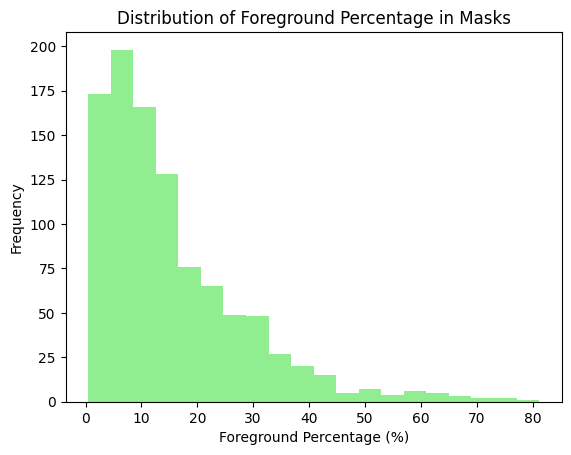

In [6]:
foreground_percentages = []
for f in image_files:
    mask_path = os.path.join(MASK_DIR, f)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        continue
    # Binarize the mask.
    _, mask_bin = cv2.threshold(mask, 128, 255, cv2.THRESH_BINARY)
    # Calculate percentage of white (foreground).
    percentage = np.sum(mask_bin == 255) / mask_bin.size * 100
    foreground_percentages.append(percentage)
    
print("Average foreground percentage: {:.2f}%".format(np.mean(foreground_percentages)))
plt.hist(foreground_percentages, bins=20, color='lightgreen')
plt.title("Distribution of Foreground Percentage in Masks")
plt.xlabel("Foreground Percentage (%)")
plt.ylabel("Frequency")
plt.show()

In [7]:
# Define transforms (example using albumentations)
train_transforms = A.Compose([
    A.Resize(512, 512), 
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    # Optionally add color jitter, small elastic transforms, etc.
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transforms = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# A custom dataset that applies these transforms.
class KvasirSegDataset(Dataset):
    def __init__(self, image_dir, mask_dir, file_list=None, transform=None):
        """
        Args:
            image_dir (str): Directory containing the images.
            mask_dir (str): Directory containing the masks.
            file_list (list, optional): List of filenames to use. If None, the 
                dataset scans the entire folder.
            transform (albumentations.Compose, optional): Transformation pipeline.
        """
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        if file_list is None:
            self.image_files = sorted([f for f in os.listdir(image_dir)
                                        if f.lower().endswith('.jpg')])
        else:
            self.image_files = sorted(file_list)
        self.transform = transform
    
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        f = self.image_files[idx]
        image_path = os.path.join(self.image_dir, f)
        mask_path  = os.path.join(self.mask_dir, f)  # Assumes masks share the same filenames.
        
        image = np.array(Image.open(image_path).convert("RGB"))
        mask  = np.array(Image.open(mask_path).convert("L"), dtype=np.uint8)
        # Binarize the mask: pixels greater than 127 become 1, else 0.
        mask = np.where(mask > 127, 1, 0).astype(np.uint8)
        
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask  = augmented['mask']
        
        return image, mask

# ---------------------------------------------------------------------
# 4. Get All Filenames and Split into Training and Validation Sets
# ---------------------------------------------------------------------
all_files = sorted([f for f in os.listdir(IMAGE_DIR) 
                    if f.lower().endswith('.jpg')])
print("Total samples:", len(all_files))

train_files, val_files = train_test_split(all_files, test_size=0.2, random_state=42)

# ---------------------------------------------------------------------
# 5. Create Dataset Instances Using the Split File Lists
# ---------------------------------------------------------------------
train_dataset = KvasirSegDataset(IMAGE_DIR, MASK_DIR, file_list=train_files, transform=train_transforms)
val_dataset   = KvasirSegDataset(IMAGE_DIR, MASK_DIR, file_list=val_files, transform=val_transforms)

print("Total training samples:", len(train_dataset))
print("Total validation samples:", len(val_dataset))

Total samples: 1000
Total training samples: 800
Total validation samples: 200


In [8]:
batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class Attention_block(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(Attention_block, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, g, x):
        g1 = self.W_g(g)  # Process gating signal.
        x1 = self.W_x(x)  # Process encoder skip.
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)  # Generate attention map.
        return x * psi  # Return gated skip connection.

class UNetResNet34_AG(nn.Module):
    def __init__(self, n_classes):
        super(UNetResNet34_AG, self).__init__()
        # Encoder: Pretrained ResNet34.
        resnet = models.resnet34(pretrained=True)
        self.layer0 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)    # Output: 64 channels [B,64,H/2,W/2]
        self.layer1 = nn.Sequential(resnet.maxpool, resnet.layer1)             # Output: 64 channels [B,64,H/4,W/4]
        self.layer2 = resnet.layer2                                             # Output: 128 channels [B,128,H/8,W/8]
        self.layer3 = resnet.layer3                                             # Output: 256 channels [B,256,H/16,W/16]
        self.layer4 = resnet.layer4                                             # Output: 512 channels [B,512,H/32,W/32]
        
        # Attention Gates for skip connections.
        # For skip connection from layer3: use gating signal from d4 (256 channels).
        self.attn3 = Attention_block(F_g=256, F_l=256, F_int=128)
        # For skip connection from layer2: use gating signal from d3 (128 channels).
        self.attn2 = Attention_block(F_g=128, F_l=128, F_int=64)
        # For skip connection from layer1: use gating signal from d2 (64 channels).
        self.attn1 = Attention_block(F_g=64, F_l=64, F_int=32)
        # For skip connection from layer0: use gating signal from d1 (64 channels).
        self.attn0 = Attention_block(F_g=64, F_l=64, F_int=32)
        
        # Decoder Blocks.
        self.upconv4 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)  # Upsample bottleneck.
        self.decoder3 = nn.Sequential(
            nn.Conv2d(256 + 256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.upconv3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.decoder2 = nn.Sequential(
            nn.Conv2d(128 + 128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.upconv2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.decoder1 = nn.Sequential(
            nn.Conv2d(64 + 64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.upconv1 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
        self.decoder0 = nn.Sequential(
            nn.Conv2d(64 + 64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.final_conv = nn.Conv2d(64, n_classes, kernel_size=1)
    
    def forward(self, x):
        # Encoder forward pass.
        x0 = self.layer0(x)   # [B,64,H/2,W/2]
        x1 = self.layer1(x0)  # [B,64,H/4,W/4]
        x2 = self.layer2(x1)  # [B,128,H/8,W/8]
        x3 = self.layer3(x2)  # [B,256,H/16,W/16]
        x4 = self.layer4(x3)  # [B,512,H/32,W/32]
        
        # Decoder with Attention Gates on skip connections.
        d4 = self.upconv4(x4)  # [B,256,H/16,W/16]
        # Apply attention gate using gating signal d4 and skip x3.
        x3_att = self.attn3(g=d4, x=x3)
        d4 = torch.cat([d4, x3_att], dim=1)  # [B,256+256,H/16,W/16]
        d4 = self.decoder3(d4)              # [B,256,H/16,W/16]
        
        d3 = self.upconv3(d4)  # [B,128,H/8,W/8]
        x2_att = self.attn2(g=d3, x=x2)
        d3 = torch.cat([d3, x2_att], dim=1)  # [B,128+128,H/8,W/8]
        d3 = self.decoder2(d3)              # [B,128,H/8,W/8]
        
        d2 = self.upconv2(d3)  # [B,64,H/4,W/4]
        x1_att = self.attn1(g=d2, x=x1)
        d2 = torch.cat([d2, x1_att], dim=1)  # [B,64+64,H/4,W/4]
        d2 = self.decoder1(d2)              # [B,64,H/4,W/4]
        
        d1 = self.upconv1(d2)  # [B,64,H/2,W/2]
        x0_att = self.attn0(g=d1, x=x0)
        d1 = torch.cat([d1, x0_att], dim=1)  # [B,64+64,H/2,W/2]
        d1 = self.decoder0(d1)              # [B,64,H/2,W/2]
        
        out = self.final_conv(d1)           # [B,n_classes,H/2,W/2]
        # **MODIFICATION:** Upsample to match input resolution (512x512)
        out = F.interpolate(out, scale_factor=2, mode='bilinear', align_corners=True)
        return out

model = UNetResNet34_AG(n_classes=1)
model = model.to(device)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 241MB/s]


In [10]:
# 7. Define Loss Function, Optimizer, and Metrics

# Loss function
loss_fn = smp.losses.DiceLoss(mode='binary')

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Metrics
iou_metric = BinaryJaccardIndex(threshold=0.5).to(device)
accuracy_metric = BinaryAccuracy(threshold=0.5).to(device)
dice_metric = Dice(threshold=0.5).to(device)

In [11]:
# -------------------------------------------------------
# 8. Training Loop
# -------------------------------------------------------
num_epochs = 25
patience = 5
best_val_loss = float('inf')
epochs_without_improvement = 0

score_history = {
    'epoch': [],
    'train_loss': [],
    'val_loss': [],
    'val_iou': [],
    'val_accuracy': [],
    'val_dice': []
}


for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device).float().unsqueeze(1)  # Ensure shape [B, 1, H, W]
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
    
    avg_train_loss = train_loss / len(train_loader.dataset)
    
    model.eval()
    val_loss = 0.0
    iou_metric.reset()
    accuracy_metric.reset()
    dice_metric.reset()
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device).float().unsqueeze(1)
            outputs = model(images)
            loss = loss_fn(outputs, masks)
            val_loss += loss.item() * images.size(0)
            
            outputs = torch.sigmoid(outputs)
            preds = (outputs > 0.5).float()
            preds_int = preds.long()
            masks_int = masks.long()
            
            # Update metrics:
            iou_metric.update(preds_int, masks_int)
            accuracy_metric.update(preds_int, masks_int)
            dice_metric.update(preds_int, masks_int)
    
    avg_val_loss = val_loss / len(val_loader.dataset)
    avg_iou = iou_metric.compute().item()
    avg_acc = accuracy_metric.compute().item()
    avg_dice = dice_metric.compute().item()
    
    # Early stopping check.
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_without_improvement = 0
        # Optionally, save the best model:
        torch.save(model.state_dict(), "/kaggle/working/KvasirUnet_34_AG_best.pth")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs.")
            break
    
    score_history['epoch'].append(epoch + 1)
    score_history['train_loss'].append(avg_train_loss)
    score_history['val_loss'].append(avg_val_loss)
    score_history['val_iou'].append(avg_iou)
    score_history['val_accuracy'].append(avg_acc)
    score_history['val_dice'].append(avg_dice)
    
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val Loss: {avg_val_loss:.4f}, Val IoU: {avg_iou:.4f}, Val Accuracy: {avg_acc:.4f}, Val Dice: {avg_dice:.4f}")

Epoch [1/25]
Train Loss: 0.4810
Val Loss: 0.2182, Val IoU: 0.6369, Val Accuracy: 0.9324, Val Dice: 0.9324
Epoch [2/25]
Train Loss: 0.2095
Val Loss: 0.1862, Val IoU: 0.6820, Val Accuracy: 0.9388, Val Dice: 0.9388
Epoch [3/25]
Train Loss: 0.1842
Val Loss: 0.1533, Val IoU: 0.7265, Val Accuracy: 0.9534, Val Dice: 0.9534
Epoch [4/25]
Train Loss: 0.1592
Val Loss: 0.1613, Val IoU: 0.7179, Val Accuracy: 0.9466, Val Dice: 0.9466
Epoch [5/25]
Train Loss: 0.1512
Val Loss: 0.1458, Val IoU: 0.7428, Val Accuracy: 0.9550, Val Dice: 0.9550
Epoch [6/25]
Train Loss: 0.1390
Val Loss: 0.1529, Val IoU: 0.7319, Val Accuracy: 0.9551, Val Dice: 0.9551
Epoch [7/25]
Train Loss: 0.1241
Val Loss: 0.1511, Val IoU: 0.7366, Val Accuracy: 0.9489, Val Dice: 0.9489
Epoch [8/25]
Train Loss: 0.1265
Val Loss: 0.1411, Val IoU: 0.7499, Val Accuracy: 0.9574, Val Dice: 0.9574
Epoch [9/25]
Train Loss: 0.1139
Val Loss: 0.1166, Val IoU: 0.7884, Val Accuracy: 0.9637, Val Dice: 0.9637
Epoch [10/25]
Train Loss: 0.1085
Val Loss: 0.1

In [12]:
torch.save(model.state_dict(), "/kaggle/working/KvasirUnet_34_AG_final.pth")

In [13]:
df_scores = pd.DataFrame(score_history)
df_scores.to_csv("/kaggle/working/KvasirUnet_34_AG_scores.csv", index=False)
print("Training scores saved.")

Training scores saved.
